# Find Gamma for Higher Resolutions
February 13, 2024

Now that we have the higher resolution model working, how long will it take to find the gamma? And can we estimate the gamma with a lower resolution version?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins()

Unflattened the input data is of shape: (16, 15, 50)
The size of our input data, G is: (16, 750)


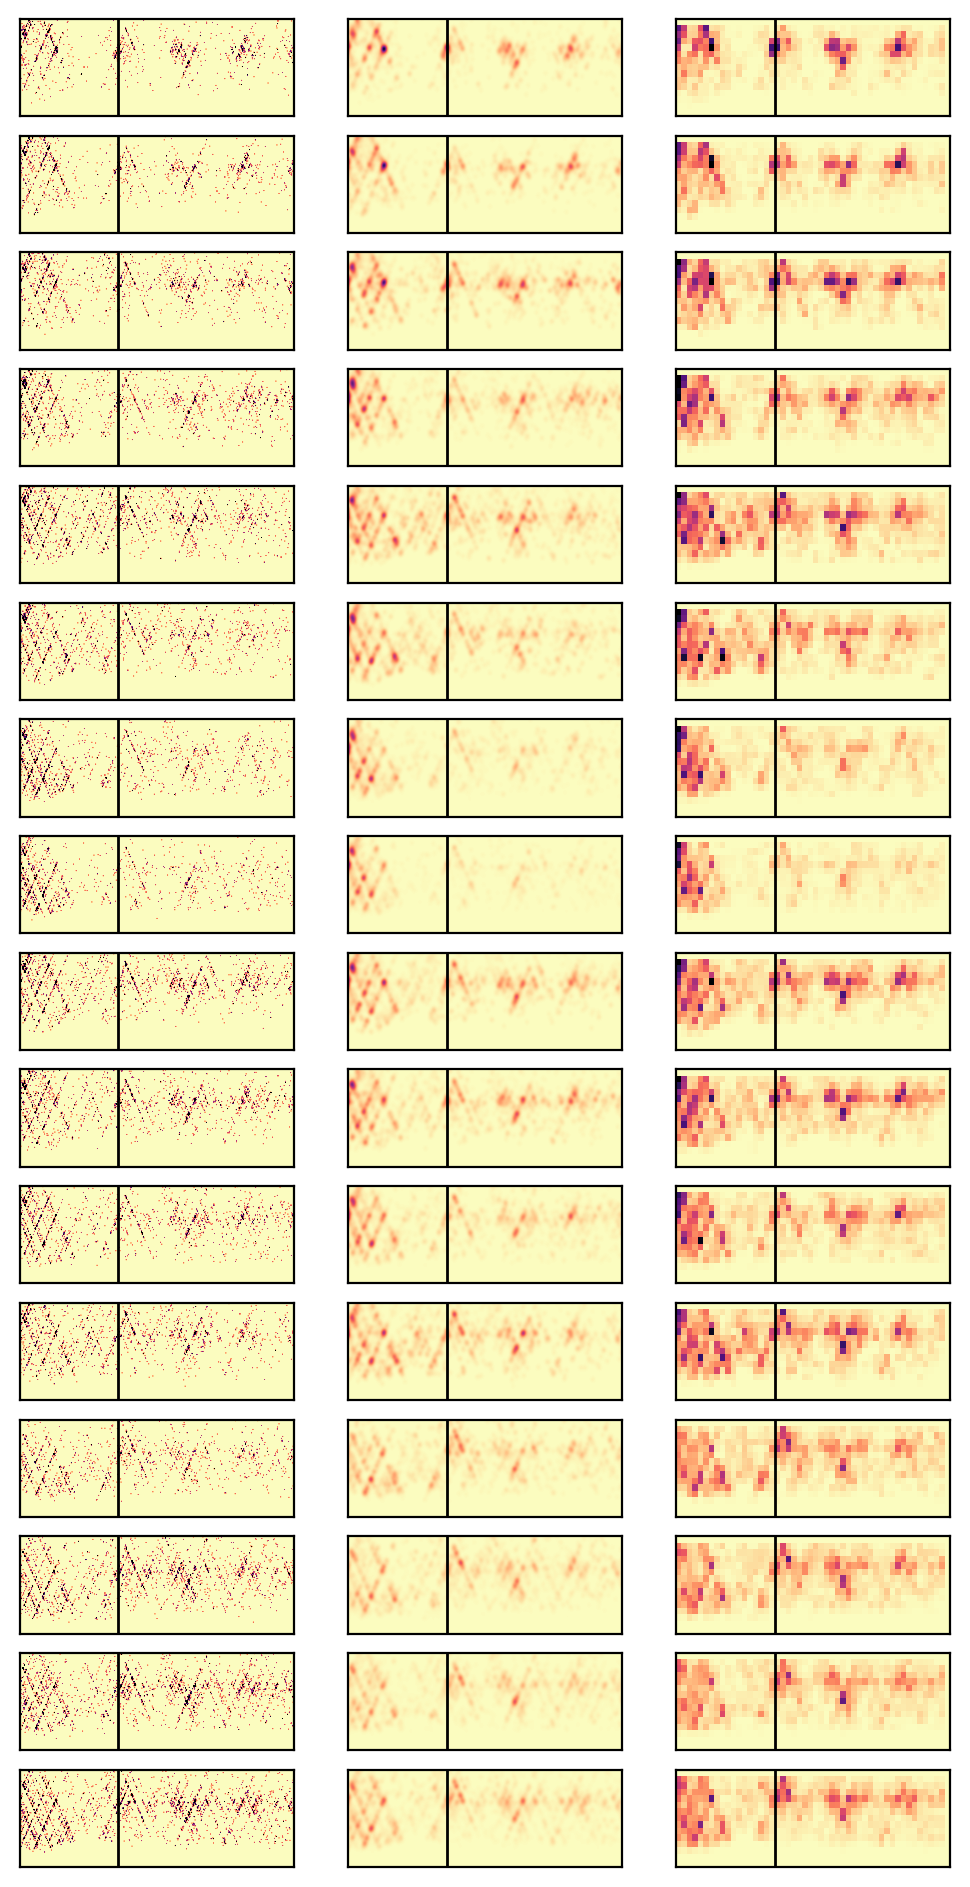

In [4]:
chromatin_model.plot_bin_comparison()

In [6]:
from src.deconvolve_chromatin import deconvolve_chromatin_H
import cvxpy

chromatin_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 3.8321
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 3.9121, rate = 2.1
  ...  search right, rn_goal = 5.3649, rate = 40.0
  ... rn range: [4.0078, 4.2595]
  ... search gamma in [0.0001 0.0100] for elbow
  ...   gm = 0.0001, rn = 4.0078, rate = 4.59, time = 00:04:59.14
  ...   gm = 0.0011, rn = 4.0311, rate = 5.19, time = 00:06:20.45
  ...   gm = 0.0021, rn = 4.0578, rate = 5.89, time = 00:07:42.56
  ...   gm = 0.0031, rn = 4.0938, rate = 6.83, time = 00:09:04.29
  ...   gm = 0.0041, rn = 4.1237, rate = 7.61, time = 00:10:26.76
  ...   gm = 0.0050, rn = 4.1503, rate = 8.30, time = 00:11:55.61
  ...   gm = 0.0060, rn = 4.1713, rate = 8.85, time = 00:13:19.59
  ...   gm = 0.0070, rn = 4.1985, rate = 9.56, time = 00:14:42.39
  ...   gm = 0.0080, rn = 4.2214, rate = 10.16, time = 00:16:08.16
  ...   gm = 0.0090, rn = 4.2

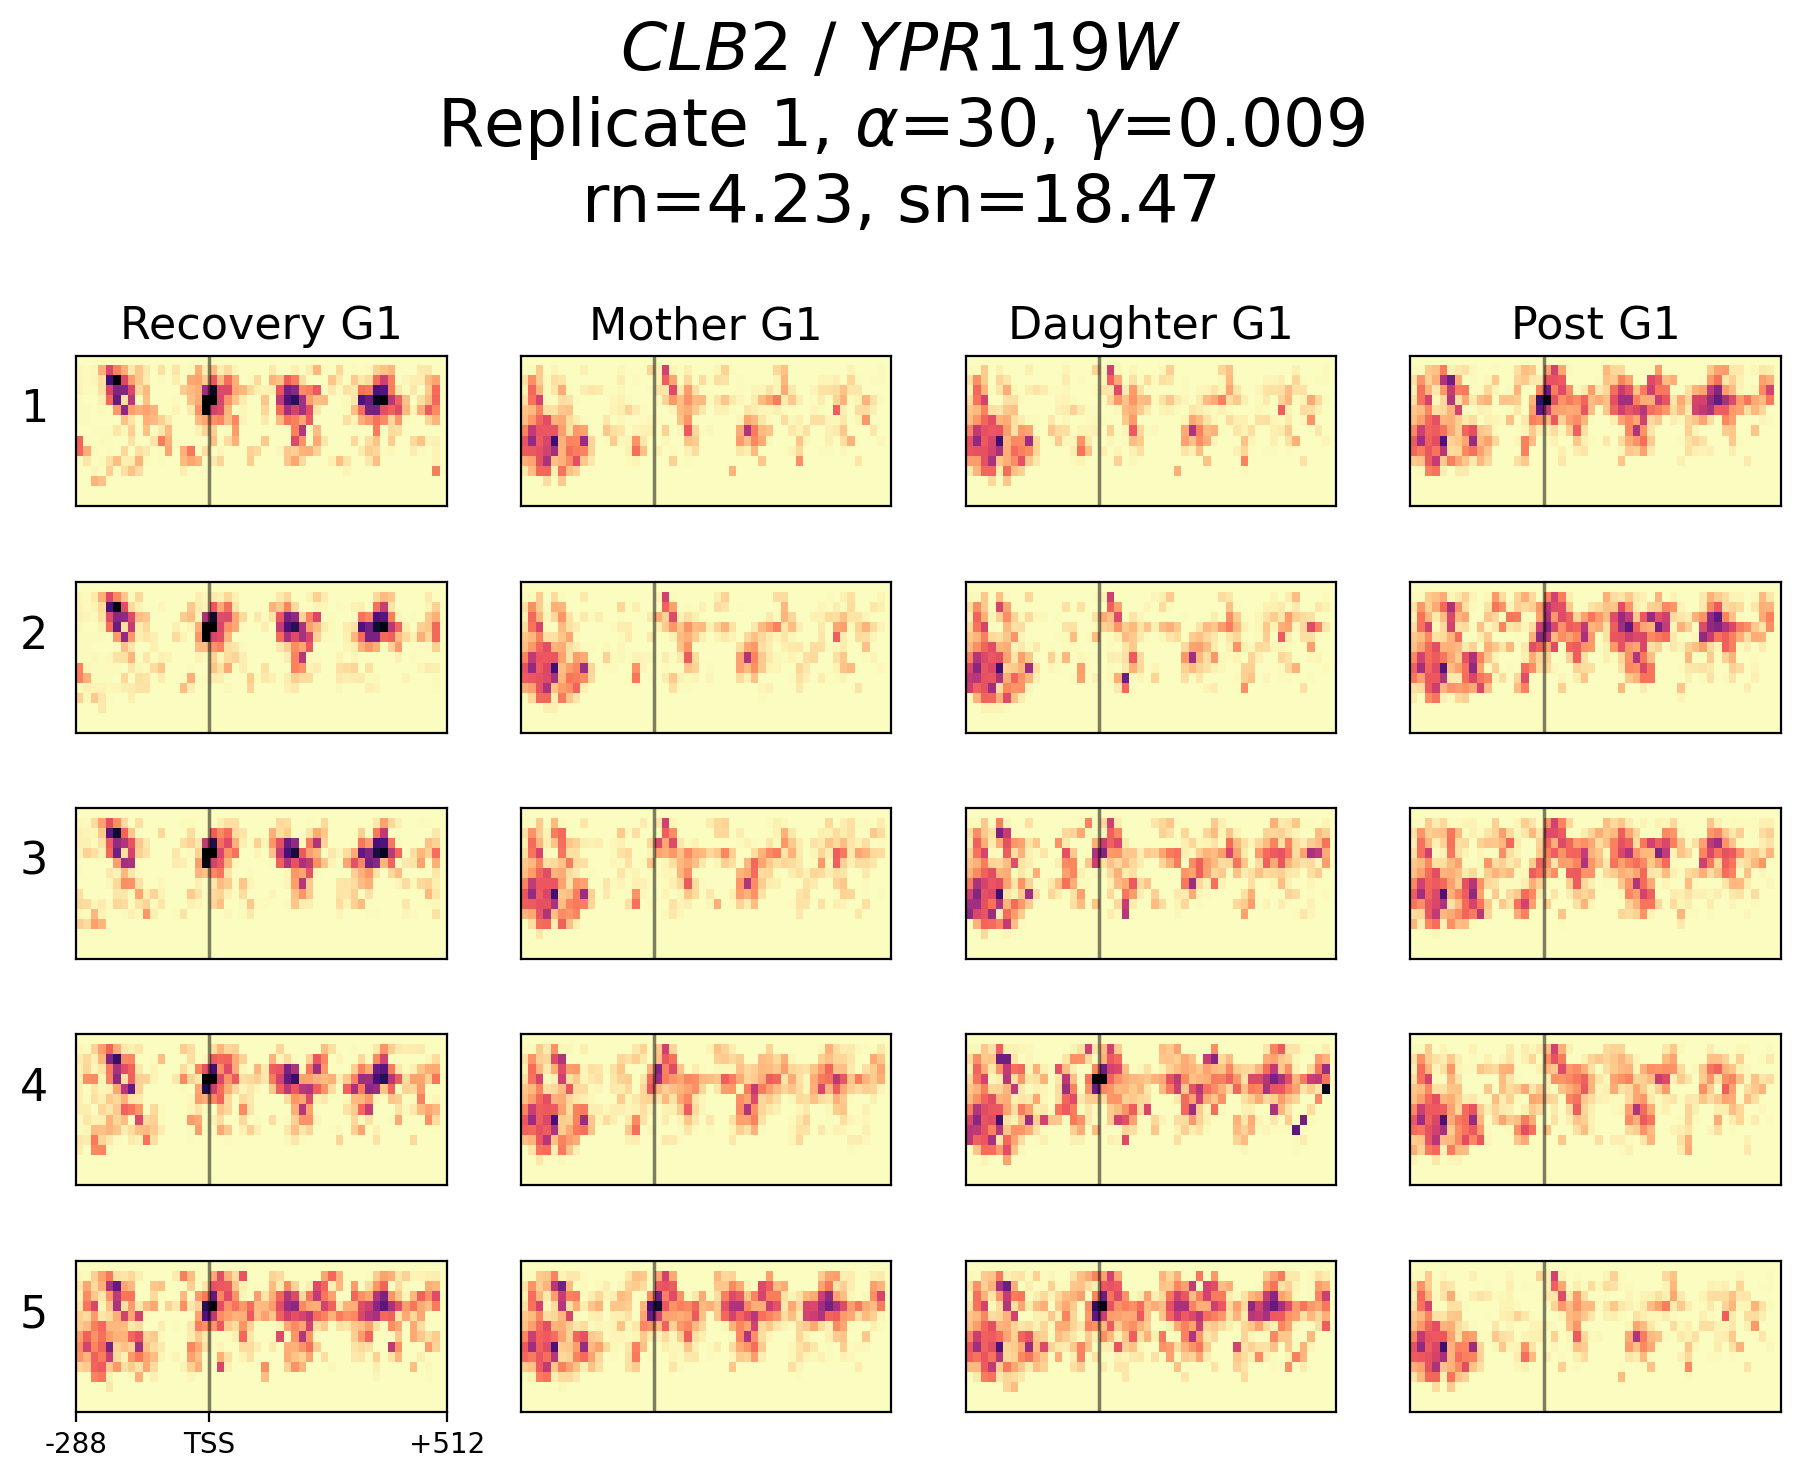

In [10]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=10)

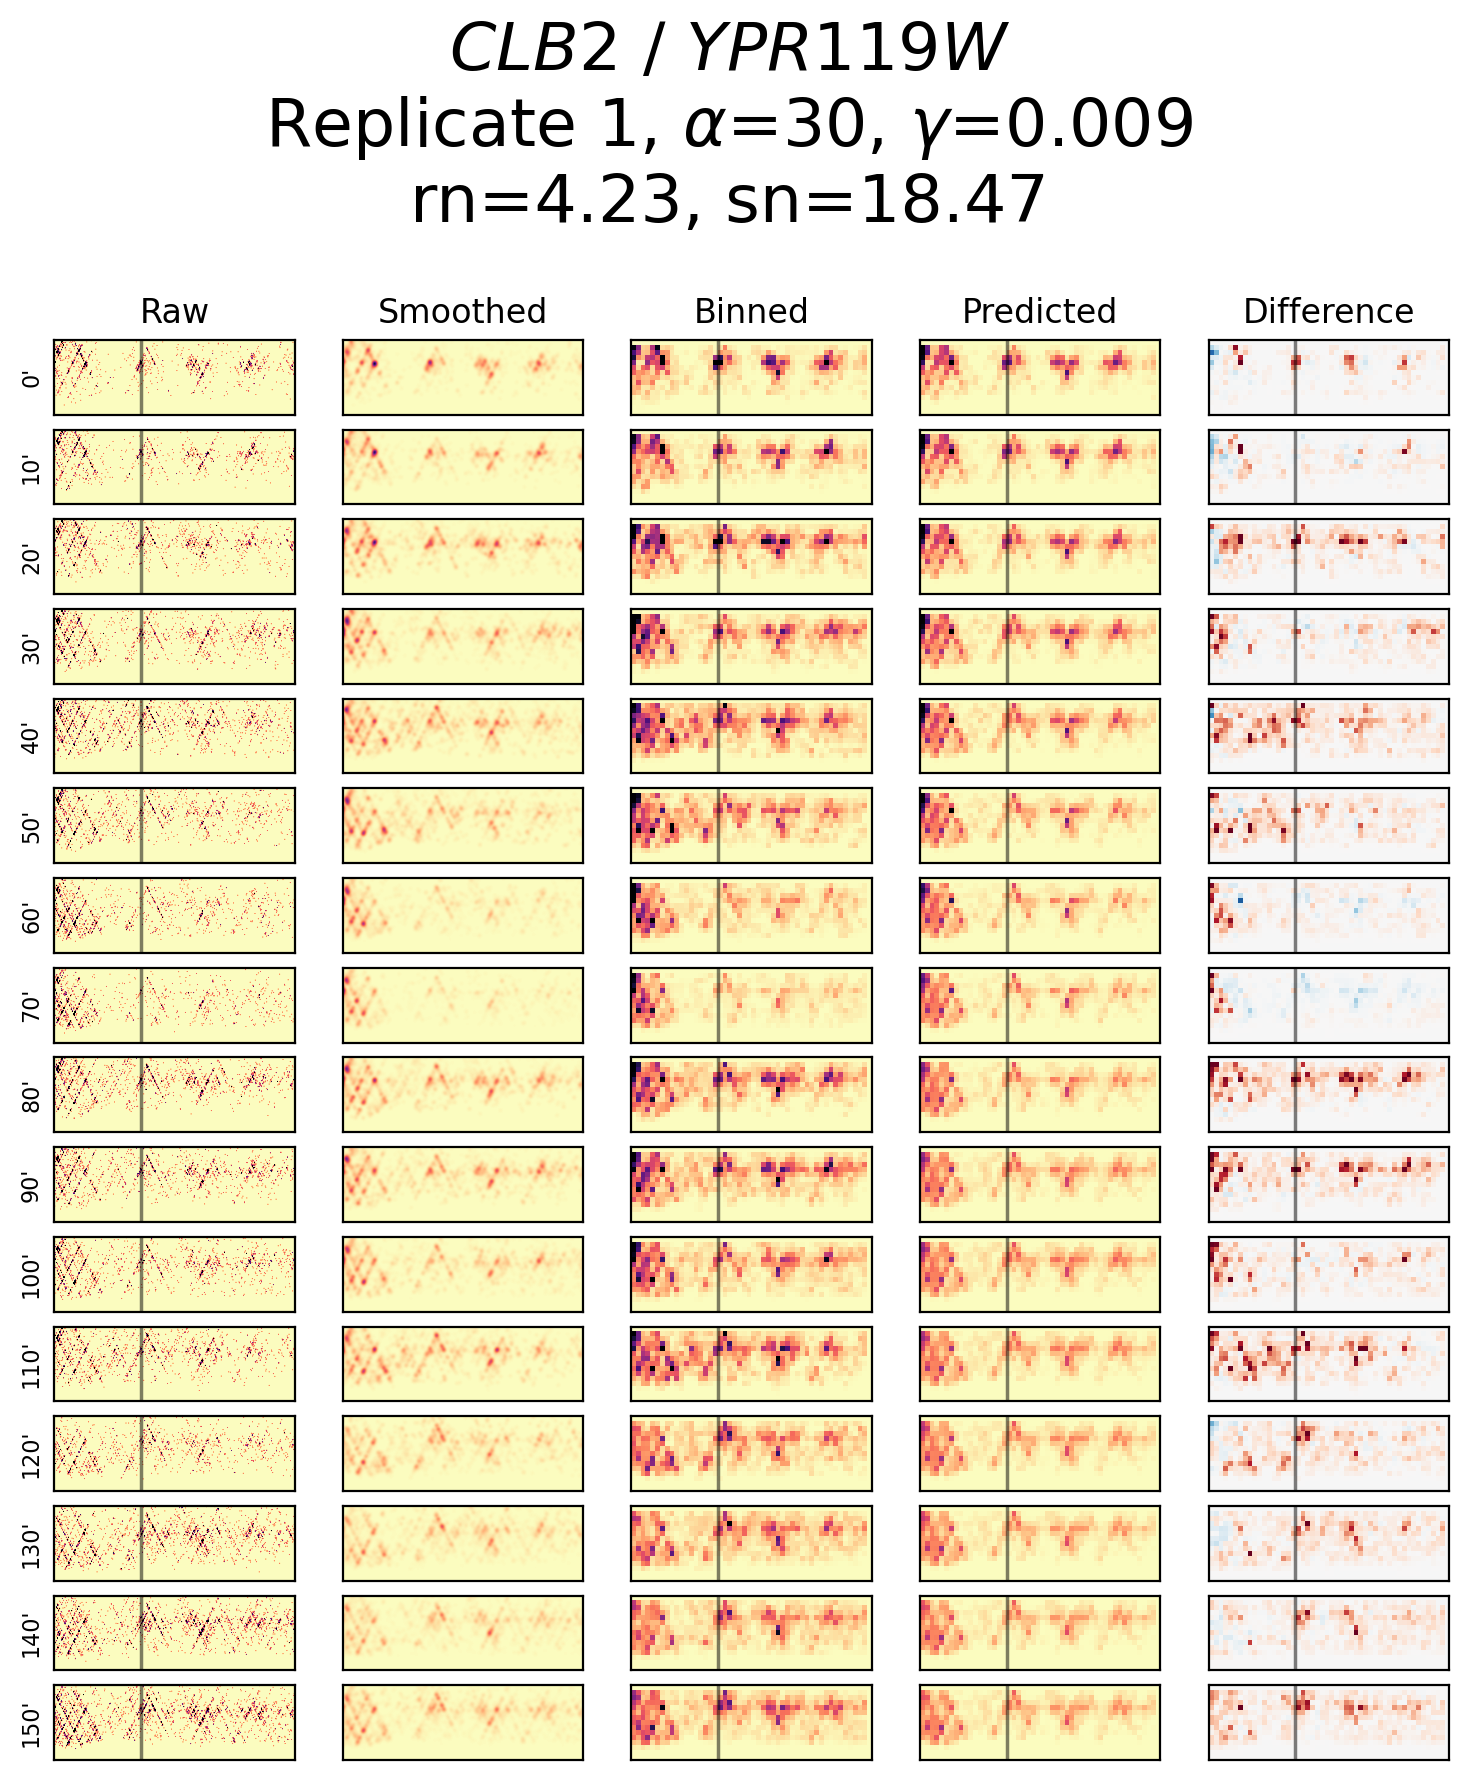

In [8]:
fig = chromatin_model.plot_prediction_comparison()

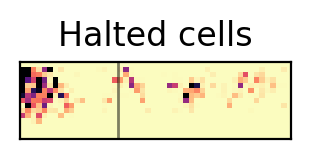

In [9]:
chromatin_model.plot_halted_f_img()